In [700]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from pathlib import Path
from aquarel import load_theme
import seaborn as sns
import scipy.stats as stats

DF_PATH = Path("../data/palmerpenguins.csv")
df = pd.read_csv(DF_PATH)

In [701]:
# look at the df
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
0,Adelie,Biscoe,53.4,17.8,219.0,5687.0,female,fish,adult,overweight,2021
1,Adelie,Biscoe,49.3,18.1,245.0,6811.0,female,fish,adult,overweight,2021
2,Adelie,Biscoe,55.7,16.6,226.0,5388.0,female,fish,adult,overweight,2021
3,Adelie,Biscoe,38.0,15.6,221.0,6262.0,female,fish,adult,overweight,2021
4,Adelie,Biscoe,60.7,17.9,177.0,4811.0,female,fish,juvenile,overweight,2021


## Cleaning

In [702]:
# shape first
df.shape

(3430, 11)

In [703]:
# info about the dataset
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 3430 entries, 0 to 3429
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            3430 non-null   str    
 1   island             3430 non-null   str    
 2   bill_length_mm     3430 non-null   float64
 3   bill_depth_mm      3430 non-null   float64
 4   flipper_length_mm  3430 non-null   float64
 5   body_mass_g        3430 non-null   float64
 6   sex                3430 non-null   str    
 7   diet               3430 non-null   str    
 8   life_stage         3430 non-null   str    
 9   health_metrics     3430 non-null   str    
 10  year               3430 non-null   int64  
dtypes: float64(4), int64(1), str(6)
memory usage: 423.3 KB


In [704]:
# fix columns
df.columns = df.columns.str.replace("_", " ")
df.columns = df.columns.str.title()

In [705]:
# check NaN values
df.isna().sum()

Species              0
Island               0
Bill Length Mm       0
Bill Depth Mm        0
Flipper Length Mm    0
Body Mass G          0
Sex                  0
Diet                 0
Life Stage           0
Health Metrics       0
Year                 0
dtype: int64

In [706]:
# change str features to category data type for performance
df[["Island", "Species", "Sex", "Diet", "Life Stage", "Health Metrics"]] = df[["Island", "Species", "Sex", "Diet", "Life Stage", "Health Metrics"]].astype("category")

In [707]:
# capitalize some column values
for col in df.select_dtypes(include="category"):
    df[col] = df[col].str.capitalize()

In [708]:
# see final df
df.head()

,Species,Island,Bill Length Mm,Bill Depth Mm,Flipper Length Mm,Body Mass G,Sex,Diet,Life Stage,Health Metrics,Year
0,Adelie,Biscoe,53.4,17.8,219.0,5687.0,Female,Fish,Adult,Overweight,2021
1,Adelie,Biscoe,49.3,18.1,245.0,6811.0,Female,Fish,Adult,Overweight,2021
2,Adelie,Biscoe,55.7,16.6,226.0,5388.0,Female,Fish,Adult,Overweight,2021
3,Adelie,Biscoe,38.0,15.6,221.0,6262.0,Female,Fish,Adult,Overweight,2021
4,Adelie,Biscoe,60.7,17.9,177.0,4811.0,Female,Fish,Juvenile,Overweight,2021


# Exploratory Data Analysis

In [709]:
# summary of numeric features
tableSummary = df.describe(include=["number"]).round(decimals=2)
tableSummary.index = tableSummary.index.str.capitalize()
# show it
tableSummary

,Bill Length Mm,Bill Depth Mm,Flipper Length Mm,Body Mass G,Year
Count,3430.00,3430.00,3430.00,3430.00,3430.00
Mean,38.53,18.45,207.03,4834.71,2023.35
Std,13.18,2.77,28.94,1311.09,1.31
Min,13.60,9.10,140.00,2477.00,2021.00
25%,28.90,16.60,185.00,3843.50,2022.00
50%,34.50,18.40,203.00,4633.50,2024.00
75%,46.60,20.30,226.00,5622.00,2024.00
Max,88.20,27.90,308.00,10549.00,2025.00


### Mean Flipper Length by Species And Sex

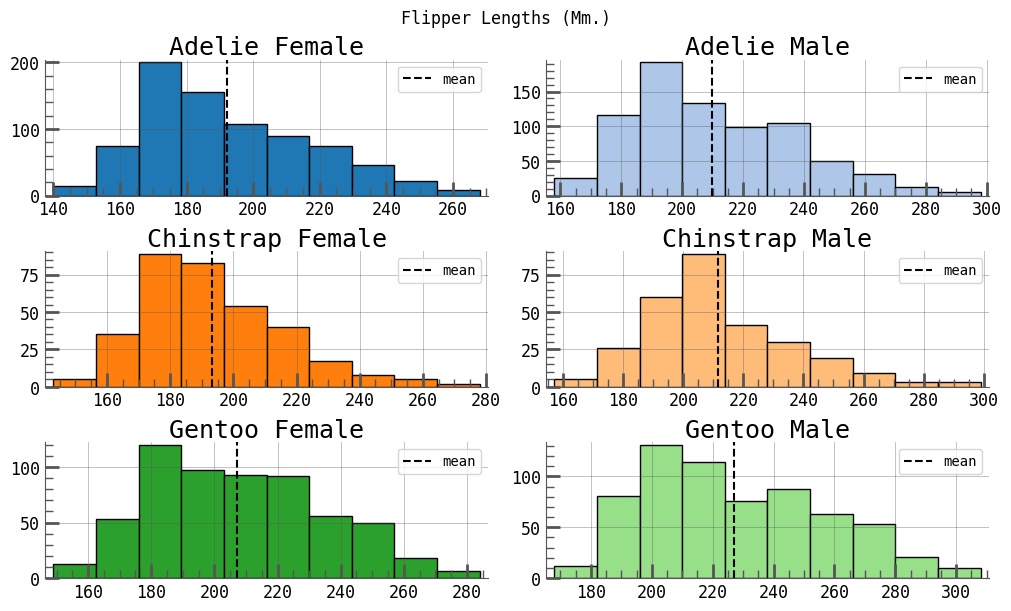

In [ ]:
# set theme
theme = load_theme("scientific").set_font(family="monospace")
theme.apply()

# set plot params
plt.rcParams.update({
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.labelcolor": "black",
    "ytick.labelcolor": "black",
})

cmap_colors = plt.get_cmap("tab20").colors
groups = df.groupby(["Species", "Sex"])

fig, axes = plt.subplots(3, 2, figsize=(10, 6), constrained_layout=True)

for ax, ((species, sex), data), color in zip(
    axes.flat,
    groups,
    cmap_colors
):
    values = data["Flipper Length Mm"]
    ax.hist(values, color=color, edgecolor="black")

    ax.axvline(
        values.mean(),
        color="black",
        linestyle="--",
        label="mean"
    )

    ax.set_title(f"{species} {sex}")
    ax.legend()

plt.suptitle("Flipper Lengths (Mm.)")
plt.show()

### Avg. Body Mass by Species and Sex

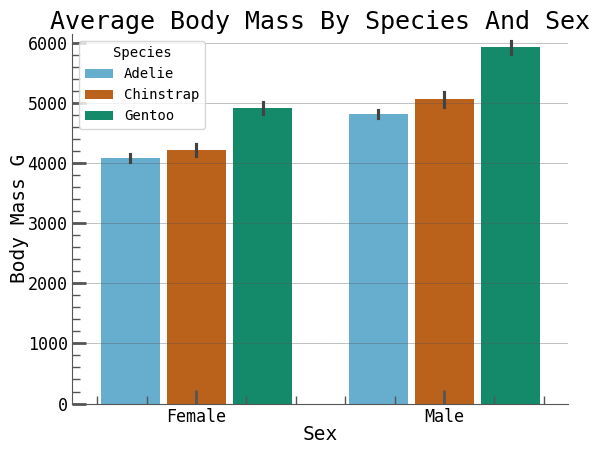

In [ ]:
sns.barplot(df, x="Sex", y="Body Mass G", hue="Species", gap=0.1, estimator="mean")
plt.title("Average Body Mass By Species And Sex")
plt.show()

### Species' Mean Body Mass



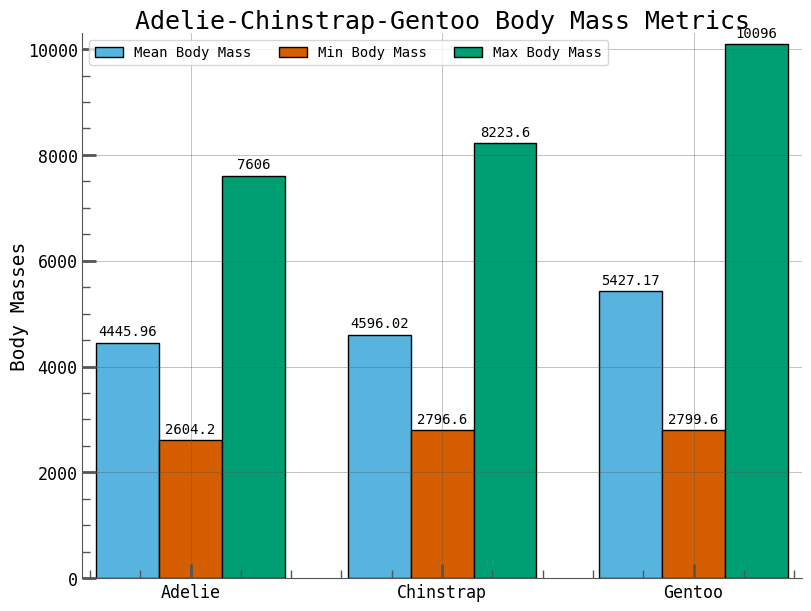

In [712]:
group = df.groupby(["Year", "Species"])["Body Mass G"].agg(["mean", "min", "max"])
species = np.array(df.Species.unique())
meanBodyMassValues = group.groupby("Species")["mean"].mean().values
minBodyMassValues = group.groupby("Species")["min"].mean().values
maxBodyMassValues = group.groupby("Species")["max"].mean().values

penguinBodyMassMeans = {
    "Mean Body Mass": meanBodyMassValues,
    "Min Body Mass": minBodyMassValues,
    "Max Body Mass": maxBodyMassValues,
}

x = np.arange(len(species))
width = 0.25 # width of the bars
multiplier = 0

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 6), constrained_layout=True)

for attribute, measurement in penguinBodyMassMeans.items():
    offset = width * multiplier
    rects = axes.bar(x + offset, measurement, width, label=attribute, edgecolor="black")
    axes.bar_label(rects, padding=3)
    multiplier += 1

axes.set_ylabel("Body Masses", color="black")
axes.set_title("Adelie-Chinstrap-Gentoo Body Mass Metrics")
axes.set_xticks(x + width, species)
axes.legend(loc="upper left", ncols=3)

plt.show()

### Comparing Juveniles vs Adults across years

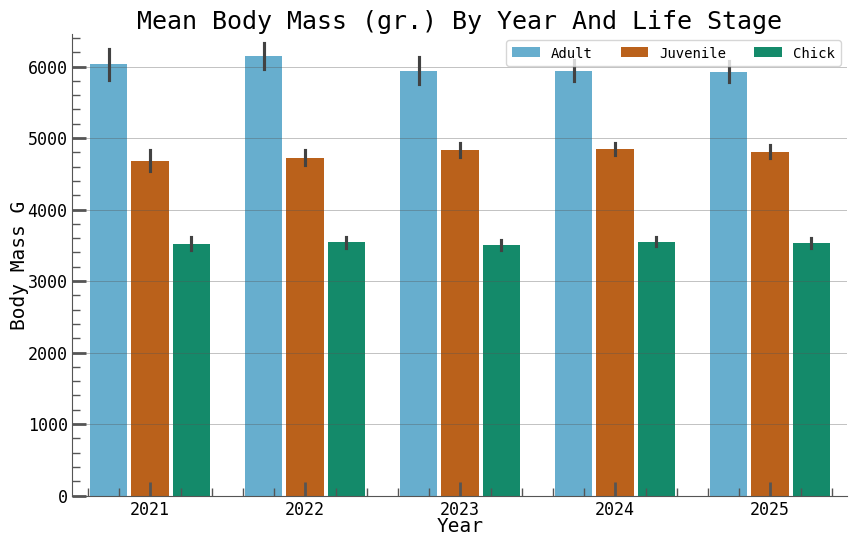

In [713]:
plt.figure(figsize=(10, 6))
sns.barplot(df, x="Year", y="Body Mass G", hue="Life Stage", estimator="mean", gap=0.1)
plt.title("Mean Body Mass (gr.) By Year And Life Stage")
plt.legend(loc="best", ncols=3)
plt.show()

### Animated Bill Depth Plot by Diet

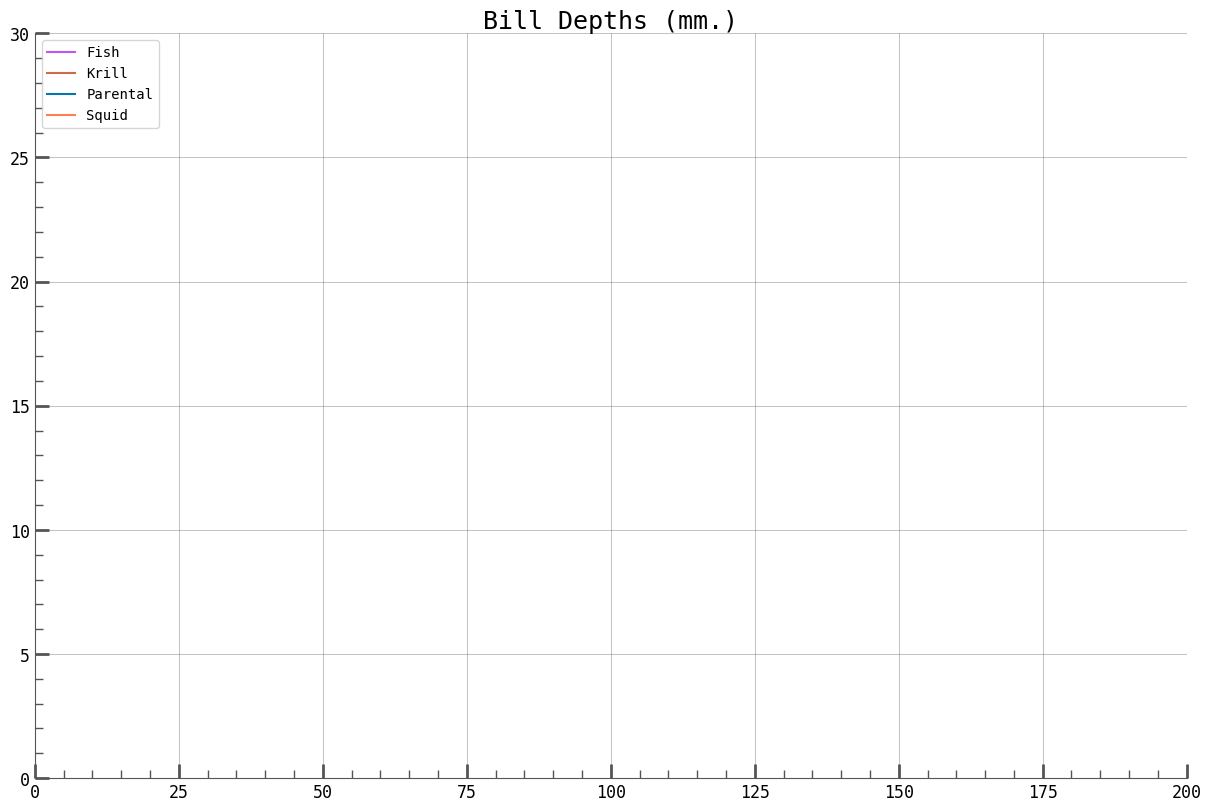

In [714]:
# animated bill depth plot by diet
from matplotlib.animation import FuncAnimation
from matplotlib import rc
rc("animation", html="jshtml")

def calcXValues(vals):
    return np.arange(0, len(vals), step=1)

fishBillDepth = df[df["Diet"] == "Fish"]["Bill Depth Mm"].values
krillBillDepth = df[df["Diet"] == "Krill"]["Bill Depth Mm"].values
parentalBillDepth = df[df["Diet"] == "Parental"]["Bill Depth Mm"].values
squidBillDepth = df[df["Diet"] == "Squid"]["Bill Depth Mm"].values

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), constrained_layout=True)

axes.set_xlim(0, 200)
axes.set_ylim(0, 30)
axes.set_title("Bill Depths (mm.)", color="black")

fishPlot, = axes.plot(calcXValues(fishBillDepth), fishBillDepth, color="#be55f7", linewidth=1.5, label="Fish")
krillPlot, = axes.plot(calcXValues(krillBillDepth), krillBillDepth, color="#ce6c4a", linewidth=1.5, label="Krill")
parentalPlot, = axes.plot(calcXValues(parentalBillDepth), parentalBillDepth, color="#0a75ad", linewidth=1.5, label="Parental")
squidPlot, = axes.plot(calcXValues(squidBillDepth), squidBillDepth, color="#ff7f50", linewidth=1.5, label="Squid")
axes.legend(loc="upper left")

def animate(frame):
    fishPlot.set_data(calcXValues(fishBillDepth[:frame]), fishBillDepth[:frame])
    krillPlot.set_data(calcXValues(krillBillDepth[:frame]), krillBillDepth[:frame])
    parentalPlot.set_data(calcXValues(parentalBillDepth[:frame]), parentalBillDepth[:frame])
    squidPlot.set_data(calcXValues(squidBillDepth[:frame]), squidBillDepth[:frame])

    return fishPlot, krillPlot, parentalPlot, squidPlot

animation = FuncAnimation(
    fig=fig,
    func=animate,
    frames=100,
    interval=20,
    repeat=True,
    blit=True
)

animation
plt.show() # remove it to run the animation

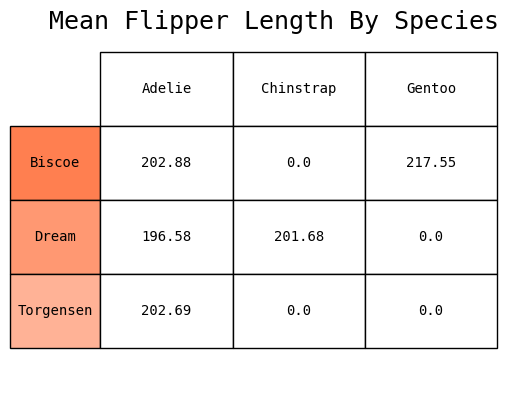

In [715]:
# pivot table
pivot = df.pivot_table(index="Island", columns="Species", values="Flipper Length Mm", aggfunc="mean", dropna=True).round(2)
# some species aren't present in some islands. I replace NaN with 0
pivot.Chinstrap = pivot.Chinstrap.replace(np.nan, 0)
pivot.Gentoo = pivot.Gentoo.replace(np.nan, 0)
pivot_colors = ["#ff7f50", "#ff9872", "#ffb296"]

plt.table(cellText=pivot.values, cellLoc="center", rowLabels=np.array(pivot.index), rowColours=pivot_colors,
          rowLoc="center", colLabels=np.array(pivot.columns), colLoc="center",
          bbox=[0.15, 0.15, 0.8, 0.8])
plt.axis("off")
plt.title("Mean Flipper Length By Species")
plt.show()

### Correlation Between Categorical And Numerical Variable

In [716]:
# are means different across Diet types?
fStat, fPValue = stats.f_oneway(
    df[df['Diet'] == 'Fish']['Body Mass G'],
    df[df['Diet'] == 'Krill']['Body Mass G'],
    df[df['Diet'] == 'Parental']['Body Mass G'],
    df[df['Diet'] == 'Squid']['Body Mass G']
)

print(f"F-stat: {round(fStat, 2)}; pValue: {fPValue}") # f-Stat is huge, so means are different across groups. This is confirmed by p-value of 0

F-stat: 1483.17; pValue: 0.0


### But which groups are different? --> Use Tukey’s Honest Significant Difference (HSD)

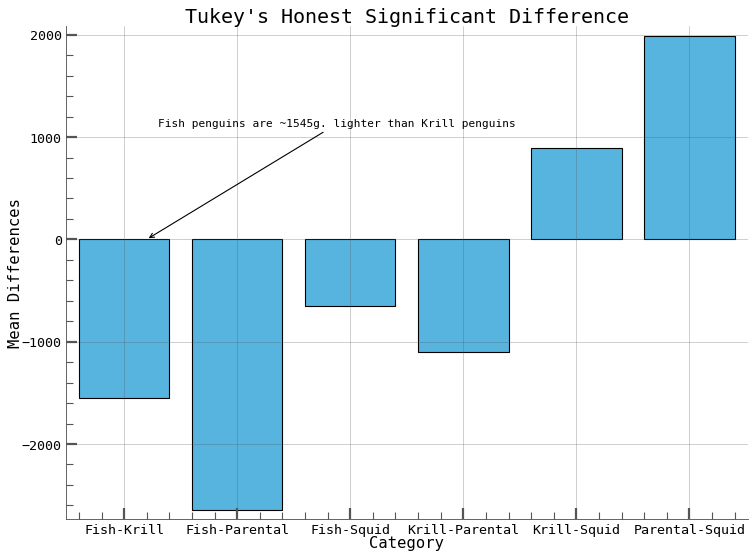

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukeyHSD = pairwise_tukeyhsd(endog=df['Body Mass G'], groups=df['Diet'], alpha=0.05)

# creating dataFrame
tukeyHSDDf = pd.DataFrame(data=tukeyHSD._results_table.data[1:], columns=tukeyHSD._results_table.data[0])
numericCols = ["meandiff", "p-adj", "lower", "upper"]
tukeyHSDDf[numericCols] = tukeyHSDDf[numericCols].astype(float)

meanDiffs = {
    f"{row['group1']}-{row['group2']}": row['meandiff']
    for idx, row in tukeyHSDDf.iterrows()
}

# plotting
plt.figure(figsize=(11, 8), dpi=80)
plt.bar(list(meanDiffs.keys()), list(meanDiffs.values()), ec="black")
plt.annotate(xy=(0.2, 0.6), xytext=(0.3, 1100),
             text=f"Fish penguins are ~1545g. lighter than Krill penguins",
             arrowprops=dict(arrowstyle="->", color="black"))
plt.title("Tukey's Honest Significant Difference")
plt.xlabel("Category")
plt.ylabel("Mean Differences", color="black")
plt.show()

## Machine Learning

In [718]:
# see if target is balanced
df.Species.value_counts()

Species
Adelie       1560
Gentoo       1247
Chinstrap     623
Name: count, dtype: int64

### Support Vector Machine Classification

In [719]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, StandardScaler

svmClassX = df[['Bill Length Mm', 'Bill Depth Mm', 'Flipper Length Mm', 'Body Mass G', 'Sex', 'Diet']]
svmClassY = df['Species']

# splitting
xTrain, xTest, yTrain, yTest = train_test_split(svmClassX, svmClassY, test_size=0.2, random_state=42)

# selecting numerical and categorical features
num_features = svmClassX.select_dtypes(include="number").columns
cat_features = svmClassX.select_dtypes(exclude="number").columns

# scale
sc = StandardScaler()
xTrainNum = sc.fit_transform(xTrain[num_features])
xTestNum = sc.transform(xTest[num_features])

# encode
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
xTrainCat = encoder.fit_transform(xTrain[cat_features])
xTestCat = encoder.transform(xTest[cat_features])

# combine
xTrainProcessed = np.hstack([xTrainNum, xTrainCat])
xTestProcessed = np.hstack([xTestNum, xTestCat])

# model
svmClass = SVC(C=2, kernel="rbf", random_state=42, class_weight="balanced")
svmClass.fit(xTrainProcessed, yTrain)
yPred = svmClass.predict(xTestProcessed)

# metrics
accScore = accuracy_score(yTest, yPred)
confMatrix = confusion_matrix(yTest, yPred)
classReport = classification_report(yTest, yPred, zero_division=0)

print(f"Accuracy Score: {accScore}")
print(f"Confusion Matrix: \n{confMatrix}")
print(f"Classification Report: \n{classReport}")

Accuracy Score: 0.5743440233236151
Confusion Matrix: 
[[170  97  37]
 [ 25  71  29]
 [ 18  86 153]]
Classification Report: 
              precision    recall  f1-score   support

      Adelie       0.80      0.56      0.66       304
   Chinstrap       0.28      0.57      0.37       125
      Gentoo       0.70      0.60      0.64       257

    accuracy                           0.57       686
   macro avg       0.59      0.57      0.56       686
weighted avg       0.67      0.57      0.60       686



### Linear Regression

In [720]:
# finding the best variables --> Flipper Length and Body Mass are the most correlated
df.corr(numeric_only=True, method="pearson")

,Bill Length Mm,Bill Depth Mm,Flipper Length Mm,Body Mass G,Year
Bill Length Mm,1.000000,0.312916,0.669066,0.661170,0.008836
Bill Depth Mm,0.312916,1.000000,0.487376,0.558539,-0.014732
Flipper Length Mm,0.669066,0.487376,1.000000,0.792182,0.007052
Body Mass G,0.661170,0.558539,0.792182,1.000000,-0.001921
Year,0.008836,-0.014732,0.007052,-0.001921,1.000000


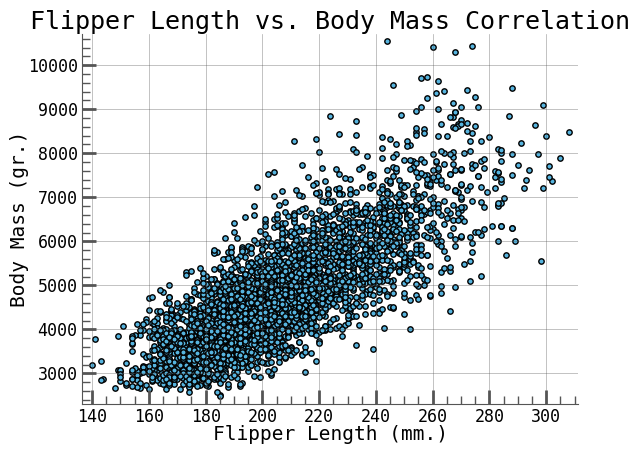

In [721]:
# visualization first
plt.scatter(df["Flipper Length Mm"], df["Body Mass G"], ec="black", s=15)
plt.xlabel("Flipper Length (mm.)")
plt.ylabel("Body Mass (gr.)")
plt.title("Flipper Length vs. Body Mass Correlation")
plt.show()

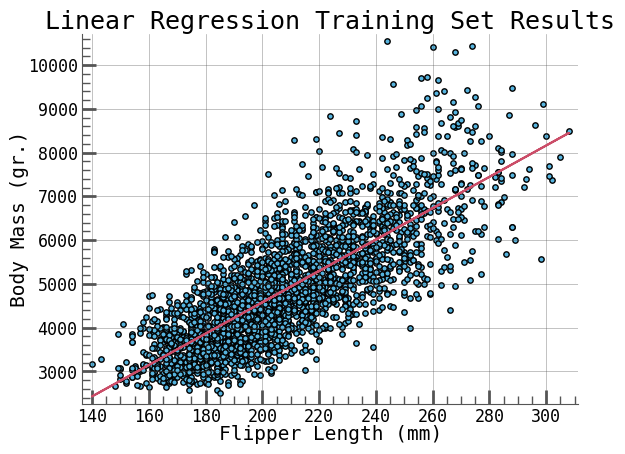

In [722]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

xRegr = df[['Flipper Length Mm']]
yRegr = df['Body Mass G']

xTrain, xTest, yTrain, yTest = train_test_split(xRegr, yRegr, test_size=0.2, random_state=42)

linReg = LinearRegression(n_jobs=-1, fit_intercept=True)
linReg.fit(xTrain, yTrain)

yPred = linReg.predict(xTest)

# metrics
r2Score = r2_score(yTest, yPred)
mse = mean_squared_error(yTest, yPred)
mae = mean_absolute_error(yTest, yPred)
rootMse = root_mean_squared_error(yTest, yPred)
mape = mean_absolute_percentage_error(yTest, yPred)

# plotting train results
plt.scatter(xTrain, yTrain, ec="black", s=15)
plt.plot(xTrain, linReg.predict(xTrain), color="#cb4d68")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (gr.)")
plt.title("Linear Regression Training Set Results")
plt.show()

In [723]:
# visualizing metrics
metrics = ["R2 Score", "MSE", "MAE", "Root MSE", "MAPE"]
metricsValues = [r2Score, mse, mae, rootMse, mape]

# creating a dataframe
metricsDf = pd.DataFrame(data=metricsValues, dtype=float, index=metrics, columns=["Value"]).round(2)

# show result
metricsDf.head()

,Value
R2 Score,0.65
MSE,581465.25
MAE,604.45
Root MSE,762.54
MAPE,0.13


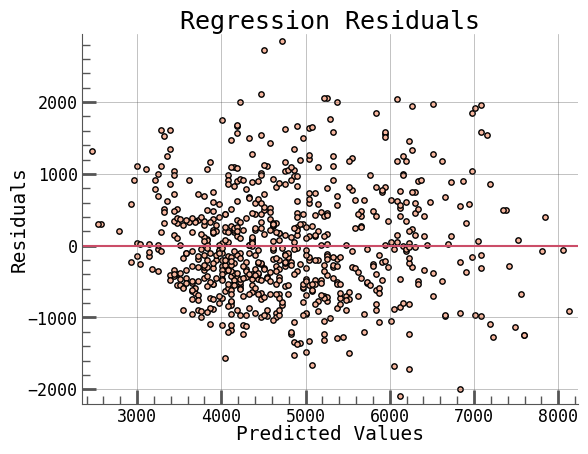

In [ ]:
# Residual plots: plot (y_true - y_pred)
residualsLinRegr = yTest - yPred

plt.scatter(yPred, residualsLinRegr, ec="black", color="#f7b69e", s=15)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.axhline(y=0, color="#cb4d68")
plt.title("Regression Residuals")
plt.show()

## Exploratory Data Analysis (EDA) Conclusions

1.	Flipper lengths among male penguins appear relatively similar across species, although Gentoo penguins exhibit somewhat higher average values. A similar pattern is observed among females.
2.	Regarding average body mass, Gentoo penguins weigh the most, followed by Chinstrap and Adelie. 
3.	From 2021 to 2025, average body mass remained relatively stable across penguin species and life stages, with only minor fluctuations among adults.
4.	I use ANOVA to see if body mass means are different across diet types and the result shows they are. The large F-statistic indicates that variation between diet groups is substantially greater than variation within groups. 
5.	Tukey’s HSD test showed statistically significant differences in mean body mass across all diet groups (p < 0.05). Penguins in the “Parental” diet category exhibited the highest mean body mass, while penguins in the “Fish” category exhibited the lowest. All pairwise comparisons were significant.

## Machine Learning Conclusions

I trained two machine learning models:
1.	SVM (Support Vector Machine): I used it to predict penguin species:
-	It achieved a 57% accuracy score, but the dataset is more skewed towards Adelie and Gentoo. Therefore, the score can’t be considered alone.
-	Because of the imbalance, the model likely performed better when predicting Adelie and Gentoo species:
1.	The model achieved higher precision for Adelie (80%) and Gentoo (70%) than for Chinstrap (28%).
2.	Recall was more balanced across classes, ranging from 56% to 60%.
3.	Because of the class imbalance, the low Chinstrap f1 score of 0.37 confirms my hypothesis further.
2.	Linear Regression using flipper length to predict body mass because they are the most correlated features:
-	The model achieved a r2 score of 0.65, which means that the model explains approximately 65% of the variance in body mass. The residual plot suggests that while the model captures the general trend, prediction errors remain substantial for many for many observations.
-	Furthermore, the Mean Absolute Error (MAE) of 604.45 indicates that, on average, the model gets a body mass prediction wrong by about 604 gr. 
-	The MAPE (Mean Absolute Percentage Error) of 0.13 means that, on average, predictions are off by 13%. 